<a href="https://colab.research.google.com/github/PreethiR091/ML-Lab/blob/main/Preethi_R_24BAD091_ML_Ex_no_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPT NO: 8 - Association Rule Learning (Apriori Algorithm) and
Dimensionality Reduction (PCA)


SCENARIO 1 – ASSOCIATION RULE MINING USING APRIORI ALGORITHM

Problem Statement

Identify frequent itemsets and generate association rules from transactional data using the Apriori algorithm.

Dataset (Kaggle – Public)

Market Basket Dataset / Grocery Dataset

Example: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset
(Any transactional dataset can be used)

Target Variable: Association rules (frequent item relationships)

Input Feature:

• Transaction ID

• Items purchased

IN-LAB TASKS

1.	Import required Python libraries (Pandas, mlxtend, etc.)
2.	Load transactional dataset
3.	Perform data preprocessing (convert to one-hot encoding format)
4.	Generate frequent itemsets using Apriori algorithm
5.	Set minimum support threshold
6.	Generate association rules
7.	Filter rules using confidence and lift
8.	Interpret rules

Evaluation Metrics

• Support

• Confidence

• Lift

Analysis Tasks

• Observe effect of support threshold on itemsets

• Identify strong association rules

• Compare rules with different confidence levels

• Analyze real-world meaning of rules

Visualization

• Bar chart of frequent itemsets

• Network graph of association rules

• Support vs confidence plots




Name: Preethi R
Roll No: 24BAD091
Experiment: Scenario 1 - Apriori Algorithm

Original Dataset:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Encoded Dataset Shape: (14963, 167)

Frequent Itemsets:
    support                 itemsets
0  0.004010  (Instant food products)
1  0.021386               (UHT-milk)
2  0.001470       (abrasive cleaner)
3  0.001938       (artif. sweetener)
4  0.008087          (baking powder)

Generated Rules:
        antecedents       consequents  antecedent support  consequent support  \
0  (tropical fruit)        (UHT-milk)            0.067767            0.021386   
1        (UHT-milk)  (tropical fruit)            0.021386            0.067767   
2     (brown bread)            (beef)            0.037626            0.033950   
3

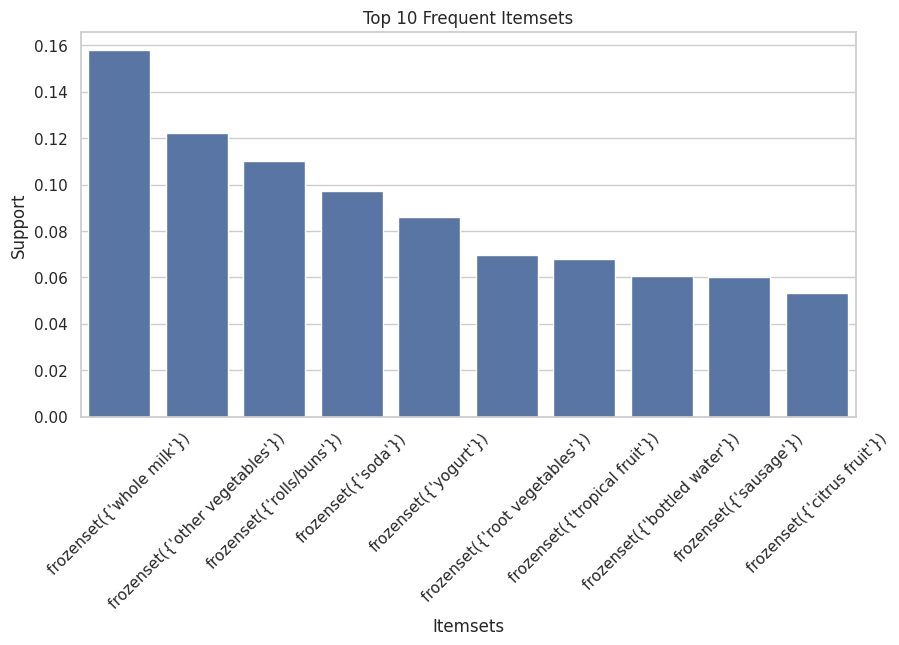

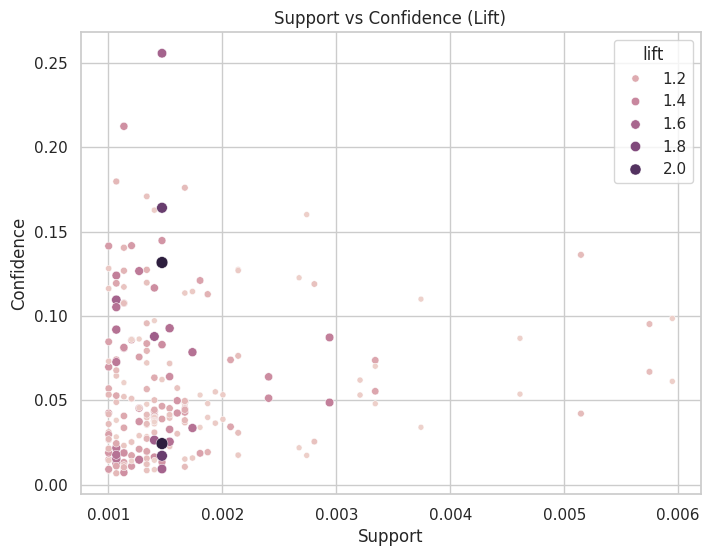

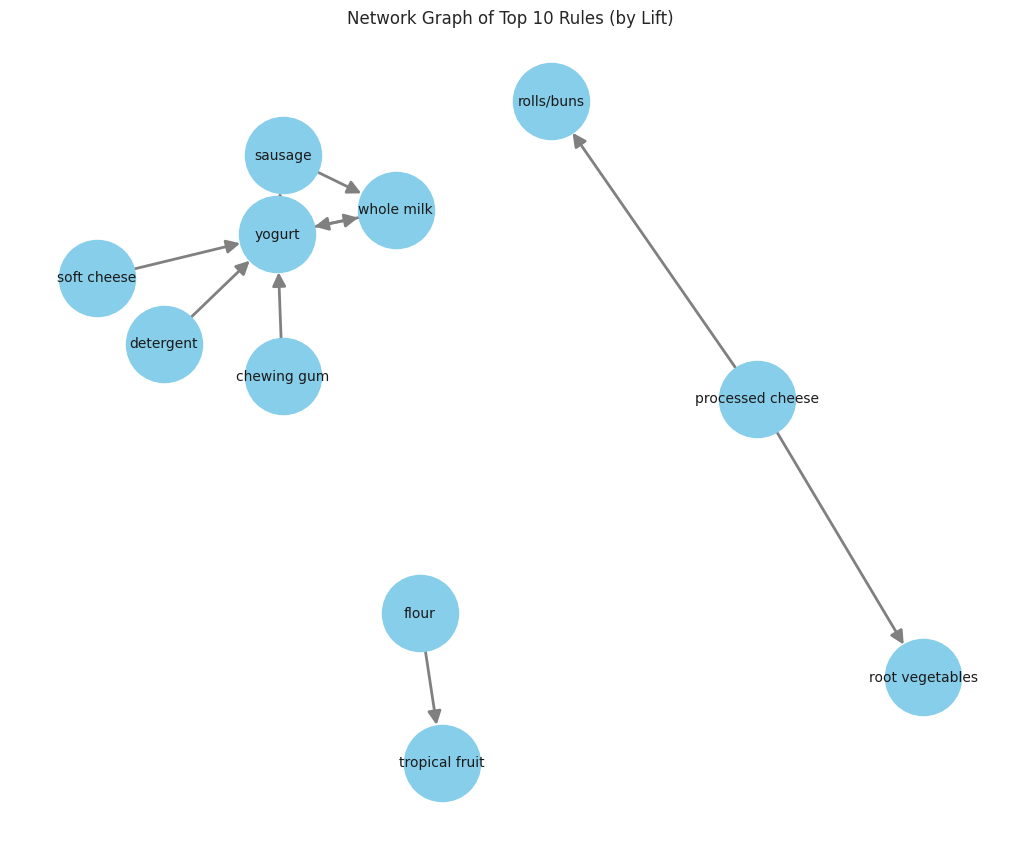

In [7]:
# Name: Preethi R
# Roll No: 24BAD091
# Experiment: Scenario 1 - Apriori Algorithm

print("Name: Preethi R")
print("Roll No: 24BAD091")
print("Experiment: Scenario 1 - Apriori Algorithm\n")

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Groceries_dataset.csv")

print("Original Dataset:")
print(df.head())

# Convert into transaction format
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'] \
                 .apply(list).values.tolist()

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("\nEncoded Dataset Shape:", df_encoded.shape)

# Apply Apriori algorithm
min_support = 0.001
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets.head())

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print("\nGenerated Rules:")
print(rules.head())

# Filter strong rules
filtered_rules = rules[(rules['confidence'] > 0.1) & (rules['lift'] > 1.2)] \
                .sort_values(by='lift', ascending=False)

print(f"\nTotal Rules Found: {len(rules)}")
print(f"Strong Rules After Filtering: {len(filtered_rules)}")

# Interpret top rules
print("\nTop Interpreted Rules:\n")

for _, row in filtered_rules.head(5).iterrows():
    print(f"{set(row['antecedents'])} → {set(row['consequents'])}")
    print(f"Support: {row['support']:.4f}")
    print(f"Confidence: {row['confidence']:.4f}")
    print(f"Lift: {row['lift']:.4f}")
    print("--------------------------------------------------")

# Bar chart (vertical)
plt.figure(figsize=(10, 5))
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

top_itemsets['itemsets'] = top_itemsets['itemsets'].astype(str)

sns.barplot(x='itemsets', y='support', data=top_itemsets)
plt.title('Top 10 Frequent Itemsets')
plt.xticks(rotation=45)
plt.xlabel('Itemsets')
plt.ylabel('Support')
plt.show()

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='support', y='confidence',
                size='lift', data=rules, hue='lift')

plt.title('Support vs Confidence (Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.show()

# Network Graph
def plot_network(rules_df, num_rules=10):
    G = nx.DiGraph()
    subset = rules_df.head(num_rules)

    for i, row in subset.iterrows():
        ant = list(row['antecedents'])[0]
        con = list(row['consequents'])[0]
        G.add_edge(ant, con, weight=row['lift'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5)

    nx.draw(G, pos, with_labels=True,
            node_color='skyblue',
            node_size=3000,
            edge_color='gray',
            font_size=10,
            width=2,
            arrowsize=20)

    plt.title(f'Network Graph of Top {num_rules} Rules (by Lift)')
    plt.show()

# Plot graph
plot_network(filtered_rules)


SCENARIO 2 – DIMENSIONALITY REDUCTION USING PCA

Problem Statement

Reduce high-dimensional data into lower dimensions while preserving maximum variance using PCA.

Dataset (Same / Alternative Dataset)

Any dataset with multiple numerical features

Example: Iris Dataset / Wine Dataset

Target Variable: Principal components (reduced feature set)

Input Features

• Numerical features (e.g., measurements, attributes)

IN-LAB TASKS

1.	Load dataset
2.	Perform data preprocessing (handling missing values, scaling)
3.	Standardize features
4.	Apply Principal Component Analysis (PCA)
5.	Compute principal components
6.	Determine explained variance ratio
7.	Reduce dimensions (e.g., 2D or 3D)
8.	Visualize transformed data

Evaluation Metrics

• Explained Variance Ratio

• Cumulative Variance

Analysis Tasks

• Analyze variance captured by each component

• Decide optimal number of components

• Compare original vs reduced data

• Observe effect on visualization

Visualization

• Scree plot (variance vs components)

• 2D/3D scatter plot of principal components

• Cumulative variance graph


Name: Preethi R
Roll No: 24BAD091
Experiment: PCA - Dimensionality Reduction

Original Dataset Shape: (150, 4)

Sample Data:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Data after Standardization:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Variance:
[0.72962445 0.95813207 0.99482129 1.   

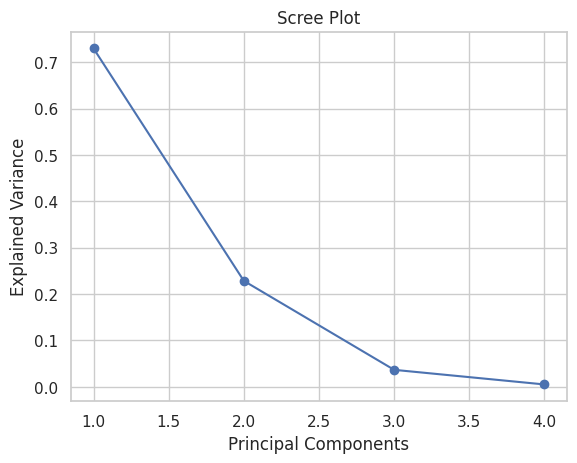

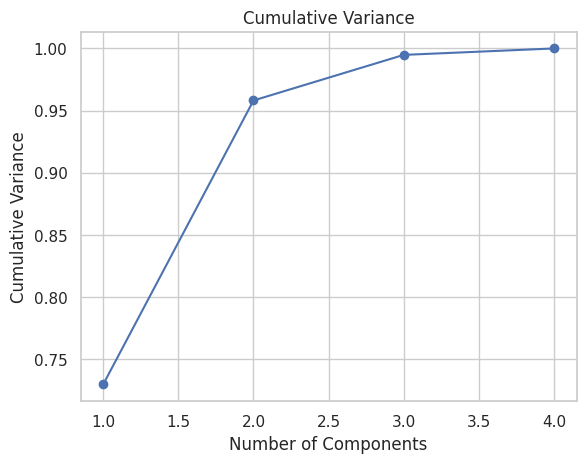

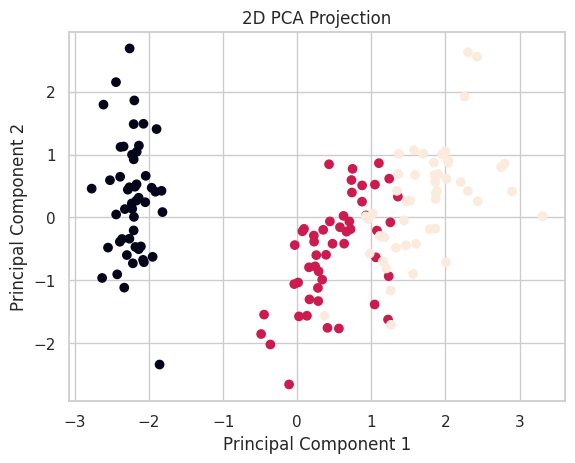

In [9]:
print("Name: Preethi R")
print("Roll No: 24BAD091")
print("Experiment: PCA - Dimensionality Reduction\n")

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset (Iris dataset)
data = load_iris()
X = data.data
y = data.target

print("Original Dataset Shape:", X.shape)

# Convert to DataFrame (for clarity)
df = pd.DataFrame(X, columns=data.feature_names)
print("\nSample Data:")
print(df.head())

# Handle missing values (if any)
df = df.dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("\nData after Standardization:")
print(X_scaled[:5])

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
print(explained_variance)

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Variance:")
print(cumulative_variance)

# Reduce to 2 components
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)

print("\nReduced Data Shape:", X_reduced.shape)

# VISUALIZATIONS

# 1. Scree Plot
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.show()

# 2. Cumulative Variance Plot
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

# 3. 2D Scatter Plot of PCA
plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection")
plt.show()
